![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)



# Tutorial to access the impact-sector application output of  Wildfire FWI

**Author**: EUMETSAT <br>
**Copyright**: 2026 EUMETSAT <br>
**Licence**: MIT <br>
**Modified by**: poladesu

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b>
<li> For Data access : <a href="https://platform.destine.eu/"> DestinE user account and access to restricted datasets</a> </li>
<li> Installation of Python packages <code class="python">destinelab tqdm xarray geopandas cartopy netCDF4 matplotlib</code></li>
</div>

This notebook demonstrates searching for and downloading the Wildfire FWI application output from the Destination Earth Data Lake.

## Import the relevant modules

Data from the impact-sector applications can be accessed via the Data Lake using simple HTTP requests with the Python package `requests`.

However, the requests need to be authenticated with the package `destinelab`. `json` is needed to handle JSON files retrieved in the search process, while `tqdm` provides a simple progress bar, `getpass` is used to safely parse passwords and `xarray` is used to visualise the retrieved data. 

In [1]:
import requests
from pathlib import Path
from urllib3.util.retry import Retry
import destinelab as deauth
import json
from getpass import getpass
from tqdm import tqdm
import xarray as xr
import geopandas
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt



## Define some constants for the API URL

In this section, we define some access points. The `COLLECTION_ID` in the first cell is a unique identifier, in our case, for the Wildfire FWI collection. The second cell contains URLs that are the same across all collections. 

The `STAC_API` is the central point for discovering data under the STAC standard on the Destination Earth Data Lake. The data is served through different collections with their own address specified here with the `COLLECTION_BY_ID_URL`. Lastly, the `SEARCH_URL` is used to query searches through the Data Lake. 


In [2]:
# Define the collection to be used

COLLECTION_ID = "EO.FMI.DAT.DESTINE_CLIMATE_WILDFIRE_FWI"

In [3]:
# STAC API
STAC_API_URL = "https://hda.data.destination-earth.eu/stac/v2"

## Collections
COLLECTION_BY_ID_URL = f"{STAC_API_URL}/collections/{COLLECTION_ID}"

## Item Search
SEARCH_URL = f"{STAC_API_URL}/search"

## Authenticate

Some collections can be accessed by everyone, but impact-sector output is restricted. Therefore, we obtain an authorisation header in the following cell by inputting our username and password.

In [4]:
from getpass import getpass as get_password

DESP_USERNAME = input("Please input your DestinE Service Platform username or email: ")
DESP_PASSWORD = get_password("Please input your DestinE Service Platform password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("Access Token Obtained Successfully")
else:
    print("Failed to Obtain Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}


Please input your DestinE Service Platform username or email:  chartick
Please input your DestinE Service Platform password:  ········


Access Token Obtained Successfully


## Discover data - Authenticated

Once authenticated, we can discover the collection by triggering a request. If successful, the collection description is displayed in JSON format. The content is identical to that available via the graphical interface at https://data.destination-earth.eu/data-portfolio and provides an overview of the collection.

Here, it is important to understand the hierarchy of an STAC collection.
1. Collection
2. Items
3. Assets (actual files)

First, we discover the collection that does not contain data files. Instead, it defines the context for all items belonging to it. The items then describe one spatiotemporal observation, or in our case, a model result. They can have multiple files associated with them and can be accessed as a whole or on a singular asset (file) basis.

In [ ]:
response = requests.get(COLLECTION_BY_ID_URL, headers=auth_headers)

print(json.dumps(response.json(), indent=4))

## Search

In the next step, we want to look at the items in a collection. As mentioned before, items are part of a collection and describe a spatiotemporal observation or snapshot, subject to flexible rules.

Wildfire FWI's items are grouped by the underlying climate model (ICON, IFS-FEOSM, IFS-NEMO) and the activity (baseline historical period or projection). The following widget helps us select one item.

In [6]:
import ipywidgets as widgets
from IPython.display import display

# Define available options
models = ["ICON", "IFS-FESOM", "IFS-NEMO"]
activity = ["projections", "baseline"]

model_widget = widgets.Dropdown(
    options=models,
    value="IFS-NEMO",
    description="Model:",
)

activity_widget = widgets.Dropdown(
    options=activity,
    value="baseline",
    description="Activity:",
)

display(model_widget, activity_widget)

def get_selection():
    return {
        "model": model_widget.value,
        "activity": activity_widget.value
    }

output = widgets.Output()

def update_output(change):
    with output:
        output.clear_output()
        selection = get_selection()
        print(f"Selected model: {selection['model']}")
        print(f"Selected activity: {selection['activity']}")

model_widget.observe(update_output, names="value")
activity_widget.observe(update_output, names="value")

display(output)

Dropdown(description='Model:', index=2, options=('ICON', 'IFS-FESOM', 'IFS-NEMO'), value='IFS-NEMO')

Dropdown(description='Activity:', index=1, options=('projections', 'baseline'), value='baseline')

Output()

Using the selected model and activity, we now search the collection for items with an HTTP request in the cell below.

It is always possible to limit the search for a date range ("datetime") and a lat/lon bounding box (bbox). Furthermore, the user can specify how results are sorted and how many entries are displayed at maximum.

Additional parameters, such as the mentioned model or activity, have to be included in the "query" part of the search request. These are individual for every collection. The impact-sector applications of Climate DT have the following 

- activity": "projections" or "baseline"
- experiment": "hist" or"ssp3-7.0"
- generation": 2,
- model "IFS-NEMO", "IFS-FESOM" or "ICON"
- realisation": 1,
- resolution": "5km"
corresponding to the matching Climate DT experiment.

The search output is provided as a JSON file containing links that can be used to download specific files and entire items directly. In the latter case, all files of an item are bundled in a zip archive.

The JSON can also be converted to a more readable dataframe with the `geopandas` package.
                



In [ ]:
selected_model = model_widget.value
selected_activity = activity_widget.value

BODY = {
    "collections": [
        COLLECTION_ID,
    ],
    "datetime": "1991-01-01T00:00:00Z/1991-01-31T00:00:00Z",
    "bbox": [-180, -90, 180, 90],
    "sortby": [{"field": "datetime", "direction": "desc"}],
    "limit": 100,
    "query":{
        "internal_fdp:activity": {
            "eq": selected_activity
       },
        "internal_fdp:model": {
            "eq": selected_model
       }
    }
}

r = requests.post(SEARCH_URL, json=BODY, headers=auth_headers)
r2 = requests.post(SEARCH_URL, json=BODY, headers=auth_headers)
if r.status_code != 200:
    (print(r.text))
r.raise_for_status()

print(json.dumps(r.json(), indent=4))

df = geopandas.GeoDataFrame.from_features(
    r.json()["features"]
)

df.head()

However, displaying an item with geopandas summarises its parameters but not the actual assets. Translating the information about the assets into a pandas DataFrame makes that possible.

We see that a Wildfire FWI item consists of a `*_T12_00_fwi.nc` file containing the meteorological fire danger conditions computed for each day, and `*_fwi_basic_and_days.nc` and `*_fwi_quantiles.nc` annual statistics files summarising key indicators derived from daily FWI values, including thresholds and quantile-based metrics, and `*_fwi_dailyclim_domain.nc` domain-averaged daily files providing aggregated FWI values over major continental regions, including Africa, Antarctica, Asia, Europe, North America, Oceania, and South America.

A more detailed description can be found in the Climate DT user guide: 
https://platform.destine.eu/services/documents-and-api/doc/?service_name=climate-dt-user-guide
                



In [8]:
item = r.json()["features"][0]

assets = pd.DataFrame.from_dict(
    item["assets"],
    orient="index"
)

assets

,href,type,title,roles,alternate
1991_fwi_basic_and_days.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_basic_and_days.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_dailyclim_Africa.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_dailyclim_Africa.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_dailyclim_Antarctica.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_dailyclim_Antarctica.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_dailyclim_Asia.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_dailyclim_Asia.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_dailyclim_Europe.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_dailyclim_Europe.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_dailyclim_NorthAmerica.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_dailyclim_NorthAmerica.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_dailyclim_Oceania.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_dailyclim_Oceania.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_dailyclim_SouthAmerica.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_dailyclim_SouthAmerica.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
1991_fwi_quantiles.nc,https://hda-download.eumetsat.data.destination...,application/netcdf,1991_fwi_quantiles.nc,[data],{'origin': {'href': 'https://s3.central.data.d...
downloadLink,https://hda-download.eumetsat.data.destination...,application/octet-stream,Download link,NaN,NaN


## Download

For datasets that require authentication, a direct download via the browser is not always possible. In this case, you can automate the download with Python. 

The following code demonstrates how to download the first item from the previous search, which contains the assets listed in the previous cell.

The code below is a bit longer than a simple download because we want to ensure a safe download with retries.  

Warning: depending on the size of the item, the download size can be considerable!

The downloaded file is a zip archive that contains all previously shown assets. In this notebook, we will not cover it further but work with single assets that we will download directly.

In [9]:
# select the first item in the result to download
product = r.json()["features"][0]

# DownloadLink is an asset representing the whole product
download_url = product["assets"]["downloadLink"]["href"]
print("Download URL:", download_url)

ITEM_ID = product["id"]
print("Item ID:", ITEM_ID)

# Create a session with retries
session = requests.Session()

retries = Retry(
    total=10,
    connect=10,
    read=10,
    backoff_factor=2,
    status_forcelist=[500, 502, 503, 504],
    allowed_methods=["GET"],
)

session.mount("https://", requests.adapters.HTTPAdapter(max_retries=retries))
session.mount("http://", requests.adapters.HTTPAdapter(max_retries=retries))

filename = Path(f"{ITEM_ID}.zip")
tmp_file = filename.with_suffix(".part")

headers = auth_headers.copy()
headers["Accept-Encoding"] = "identity"

with session.get(
    download_url,
    headers=headers,
    stream=True,
    timeout=(30, 300),  # connect timeout, read timeout
) as response:

    response.raise_for_status()

    total_size = int(response.headers.get("Content-Length", 0))

    with open(tmp_file, "ab") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
        desc=filename.name,
    ) as pbar:

        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

tmp_file.rename(filename)

print(f"Downloaded to {filename}")

Download URL: https://hda-download.eumetsat.data.destination-earth.eu/data/internal_fdp/EO.FMI.DAT.DESTINE_CLIMATE_WILDFIRE_FWI/EO.FMI.DAT.DESTINE_CLIMATE_WILDFIRE_FWI_19910101T000000_19911231T230000__IFS-NEMO__historical__2__1__high__baseline__yearly/downloadLink
Item ID: EO.FMI.DAT.DESTINE_CLIMATE_WILDFIRE_FWI_19910101T000000_19911231T230000__IFS-NEMO__historical__2__1__high__baseline__yearly


EO.FMI.DAT.DESTINE_CLIMATE_WILDFIRE_FWI_19910101T000000_19911231T230000__IFS-NEMO__historical__2__1__high__baseline__yearly.zip: 100%|██████████| 824M/824M [00:23<00:00, 37.5MB/s] 

Downloaded to EO.FMI.DAT.DESTINE_CLIMATE_WILDFIRE_FWI_19910101T000000_19911231T230000__IFS-NEMO__historical__2__1__high__baseline__yearly.zip


## Download a single asset (file) with Python

If you are only interests in a single asset it is much more conviniant to download a singel asset.
In the example below, we extract a one-day FWI file, one yearly statistics file for each of `*_fwi_basic_and_days.nc` and `*_fwi_quantiles.nc`, and one domain file for Europe, `*_fwi_dailyclim_Europe.nc`, from the Wildfire FWI collection and investigate their contents in further steps.


In [10]:
for suffix in ("T12_00_fwi.nc", "_fwi_basic_and_days.nc","_fwi_quantiles.nc","_fwi_dailyclim_Europe.nc"):
    url = next(
        asset["href"]
        for feature in r2.json()["features"]
        for asset in feature.get("assets", {}).values()
        if asset.get("title", "").endswith(suffix)
    )

    print(f"Downloading {url}")

    local_file = url.rsplit("/", 1)[-1]

    response = requests.get(url, stream=True, headers=auth_headers)
    response.raise_for_status()

    total_size = int(response.headers.get("Content-Length", 0))

    with open(local_file, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=f"Downloading {local_file}",
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                progress_bar.update(len(chunk))


## Plot the downloaded files

The downloaded netCDF file can be directly visualised with xarray.

The code below visualises the extreme FWI threshold days based on the European Forest Fire Information System (EFFIS).

In [16]:
# Ploting routine
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point


def plot_one(var_name, file="1991_fwi_basic_and_days.nc", cmap="viridis",
             vmin=None, vmax=None, title=None):
    ds = xr.open_dataset(file)
    da = ds[var_name]

    # Standardize longitude from 0..360 to -180..180
    da = da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

    # Add cyclic point so the map has no seam
    vals, lon = add_cyclic_point(da.values, coord=da.lon.values, axis=-1)

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    p = ax.pcolormesh(
        lon,
        da.lat.values,
        vals,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto"
    )

    ax.add_feature(cfeature.LAND, facecolor="0.95", zorder=0)
    ax.coastlines(linewidth=0.6)
    ax.set_title(title or var_name)

    plt.colorbar(p, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
    plt.show()

    return fig, ax



def plot_model_cycle(var_name="fwi", file="1991_fwi_dailyclim_Europe.nc",
                     title=None, y_label="Fire Weather Index",
                     color="#DC143C"):
    ds = xr.open_dataset(file)
    da = ds[var_name]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(da.time.dt.dayofyear, da, color=color, lw=2.5)

    ax.set_xlim(1, 365)
    ax.set_xlabel("Day of year")
    ax.set_ylabel(y_label)
    ax.set_title(title or var_name)
    ax.grid(True, alpha=0.3)

    plt.show()
    return fig, ax

Using file: 1991_fwi_basic_and_days.nc


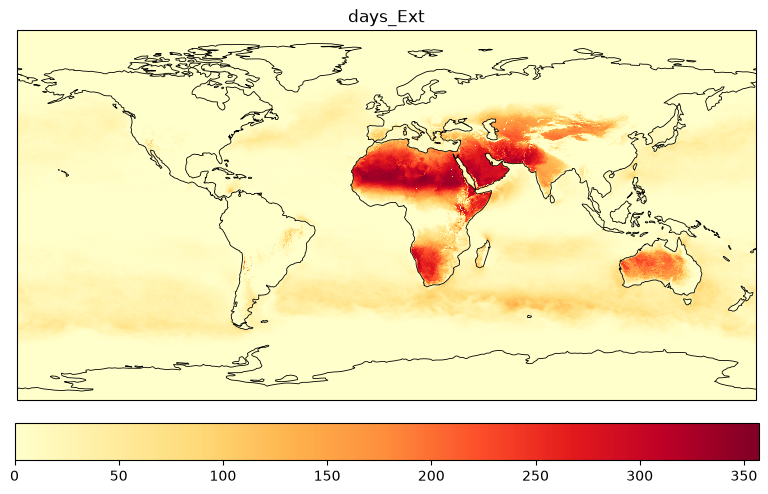

(<Figure size 1200x600 with 2 Axes>, <GeoAxes: title={'center': 'days_Ext'}>)

In [17]:
local_file = next(Path(".").glob("*_fwi_basic_and_days.nc"))

print(f"Using file: {local_file}")

ds = xr.open_dataset(local_file)

plot_one("days_Ext", cmap="YlOrRd")


Finally, we take a look at the FWI seasonal cycle averaged over European land for this specific year.


Using file: 1991_fwi_dailyclim_Europe.nc


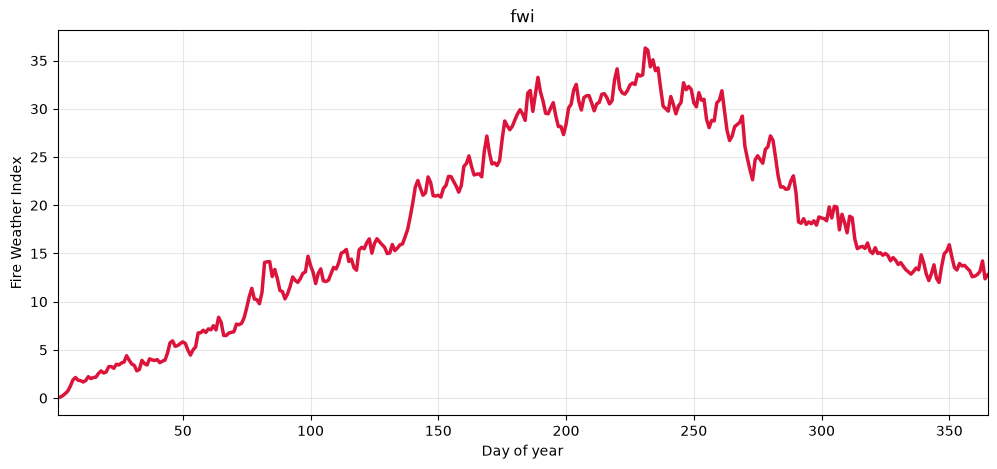

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'fwi'}, xlabel='Day of year', ylabel='Fire Weather Index'>)

In [18]:
local_file = next(Path(".").glob("*fwi_dailyclim_Europe.nc"))

print(f"Using file: {local_file}")

ds_sea = xr.open_dataset(local_file)

ds_sea

plot_model_cycle("fwi")